# N-HiTS 안정화 학습 — 결정적 배치, LR 스케줄러, 검증셋 조정

`03_nhits_model.ipynb`을 실행하면서 train/val loss가 epoch마다 들쭉날쭉 튀는 걸 관찰했고,
원인을 다음과 같이 진단했습니다(자세한 설명은 대화 기록 및 `docs/도메인_배경지식.md` 참고).

1. **`limit_train_batches=60`이 매 epoch마다 무작위로 다른 배치를 뽑음** — 전체 1,044개
   배치 중 5~6%만 매번 랜덤하게 골라 쓰다 보니, 어떤 epoch은 우연히 변동이 심한 구간을
   많이 학습하고 어떤 epoch은 그렇지 않아 손실이 들쭉날쭉했습니다.
2. **학습률(0.03)이 고정값이고 감쇠(decay)가 없음** — 학습이 진행돼도 항상 같은 크기로
   갱신하다 보니 이미 수렴한 뒤에도 가끔 최적점을 넘어서는(overshoot) 일이 생겼습니다.
3. **검증셋이 작음(991개 윈도우)** — 검증 손실 자체도 통계적으로 들쭉날쭉할 수 있습니다.

이 노트북은 세 가지를 모두 고쳐서 다시 학습합니다.

- **무작위성 제거**: `limit_train_batches`로 매 epoch 무작위 일부만 쓰는 대신, **매 epoch
  전체 데이터를 다 사용**합니다. (아래 "왜 일부만 고정해서 쓰지 않았는가" 참고 — 작은
  고정 구간만 반복 학습하면 오히려 그 구간에 과적합되는 더 나�쁜 문제가 생긴다는 것을
  실험으로 확인했습니다.)
- **학습률 스케줄러 + 감쇠**: 학습 시작 전 Lightning의 `Tuner.lr_find`로 이 데이터에 맞는
  적정 학습률을 자동으로 탐색하고, 학습 중에는 `ReduceLROnPlateau`로 검증 손실이 정체되면
  학습률을 자동으로 줄여나갑니다(고정값 대신 "필요할 때 스스로 줄어드는" 방식).
- **검증셋 확대**: 검증 구간 길이를 2배로 늘려(991 → 약 1,991개 윈도우) 검증 손실 자체의
  통계적 흔들림을 줄였습니다. (학습 데이터에서 아주 적은 비율만 빠지므로 학습에는 거의
  영향이 없습니다.)

> **트레이드오프 안내**: 매 epoch 전체 데이터를 쓰기 때문에, 이 노트북은 `03_nhits_model.ipynb`
> (매 epoch 60개 배치만 사용)보다 **1 epoch당 시간이 더 오래 걸립니다** (이 환경 기준 약
> 30~40초/epoch, 전체 학습은 수 분~10분 내외). 대신 학습이 훨씬 안정적이고, 실제로 몇 번을
> 다시 실행해도 같은 패턴으로 수렴합니다.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightning.pytorch as pl
from lightning.pytorch.tuner import Tuner
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback

# torch>=2.6부터 torch.load 기본값이 weights_only=True로 바뀌면서, Lightning 내부의
# 체크포인트 저장/복원 로직(학습률 자동탐색(lr_find), 학습 재개 등)이 pytorch_forecasting의
# 정규화 객체(GroupNormalizer 등)를 불러오지 못해 실패한다. 우리가 이 노트북 안에서 직접
# 생성한, 신뢰할 수 있는 체크포인트만 다루므로 torch.load의 기본값을 weights_only=False로
# 되돌려서 우회한다.
_orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    """torch.load를 감싸 weights_only 기본값을 False로 강제하는 래퍼.
    (직접 저장한 체크포인트를 다시 불러올 때만 쓰이므로 안전하다.)"""
    kwargs["weights_only"] = False
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

from pytorch_forecasting import NHiTS, TimeSeriesDataSet
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
pl.seed_everything(42, verbose=False)

# 한글 폰트 설정
_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints_stable")
os.makedirs(CKPT_DIR, exist_ok=True)
LAST_CKPT_PATH = os.path.join(CKPT_DIR, "last.ckpt")

ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available(), "| 학습 장치:", ACCELERATOR)


torch: 2.6.0+cu124 | CUDA available: True | 학습 장치: gpu


## 1. 데이터 로드 및 전처리 (03번과 동일)

In [2]:
def load_clean(path):
    """CSV 파일을 읽고 컬럼명 앞뒤 공백을 제거해서 반환한다.
    (원본 CSV 헤더에 공백이 섞여 있어 그대로 쓰면 컬럼 접근 시 KeyError가 날 수 있다.)"""
    df = pd.read_csv(path)
    return df.rename(columns=lambda c: c.strip())


def adjust(df):
    """N-HiTS 입력용 'value' 컬럼 생성: RealPower가 1300 미만이면 930.5를 더해
    저전력/고전력 두 그룹의 스케일 차이를 줄인다 (가이드북 [코드 31] 동일 로직).
    'time_idx'는 해당 데이터프레임 내에서 0부터 새로 부여하고, 단일 시계열이므로
    'series'는 상수 '0'으로 둔다."""
    df = df.copy()
    df["value"] = df["RealPower"].astype(float)
    df.loc[df["RealPower"] < 1300, "value"] += 930.5
    df["time_idx"] = np.arange(len(df))
    df["series"] = "0"
    return df


train_raw = load_clean(f"{DATA_DIR}/raw_data/train/Training_Data.csv")
train = adjust(train_raw)
print("train shape:", train.shape)
train[["RealPower", "SetPower", "value", "time_idx"]].head()


train shape: (135759, 12)


,RealPower,SetPower,value,time_idx
0,1688,82,1688.0,0
1,1713,83,1713.0,1
2,1695,82,1695.0,2
3,1717,83,1717.0,3
4,1698,82,1698.0,4


## 2. 학습/검증 데이터셋 구성 — 검증셋을 2배로 확대

03번은 `training_cutoff = time_idx.max() - 100 * max_prediction_length`로 검증 윈도우가
991개였습니다. 여기서는 배수를 200으로 늘려 검증 윈도우를 약 1,991개로 2배 확대합니다.
전체 학습 데이터(135,759행)에서 보면 검증에 더 할애하는 양(약 1,000행)이 미미해서 학습에는
거의 영향이 없으면서, 검증 손실의 통계적 흔들림은 줄어듭니다.

In [3]:
max_encoder_length = 20
max_prediction_length = 10
VALIDATION_CUTOFF_MULTIPLIER = 200  # 03번은 100 -> 991개 윈도우. 여기서는 200 -> 약 1,991개.
training_cutoff = train["time_idx"].max() - VALIDATION_CUTOFF_MULTIPLIER * max_prediction_length

training = TimeSeriesDataSet(
    train[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["series"],
    time_varying_unknown_reals=["value"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)
validation = TimeSeriesDataSet.from_dataset(training, train, min_prediction_idx=training_cutoff + 1)

batch_size = 128
# shuffle=True(기본값)로 두되, limit_train_batches를 지정하지 않아 매 epoch 전체 배치를 다
# 사용한다. "순서"는 매 epoch 섞이지만(표준적인 방식), "어떤 데이터를 쓰는가"는 항상
# 전체 데이터로 고정되어 있어 03번의 무작위 서브샘플링 문제가 사라진다.
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"학습 윈도우 수: {len(training)}, 검증 윈도우 수: {len(validation)}")
print(f"1 epoch당 배치 수: {len(train_dataloader)} (03번의 60개와 달리 매 epoch 전부 사용)")


학습 윈도우 수: 133730, 검증 윈도우 수: 1991
1 epoch당 배치 수: 1044 (03번의 60개와 달리 매 epoch 전부 사용)


## 3. 학습률 자동 탐색 (LR Finder)

`lightning.pytorch.tuner.Tuner.lr_find`로 학습을 시작하기 전에 짧은 시험 학습(기본 100
스텝)을 돌려서, 손실이 가장 가파르게 줄어드는 지점의 학습률을 자동으로 추천받습니다.
추천값을 그대로 쓰면 데이터셋/설정에 따라 지나치게 작은 값이 나올 때도 있어(직접 실험해본
결과, 이 자동 추천값은 실행마다 편차가 꽤 컸습니다), 상식적인 범위(`[1e-3, 5e-2]`)를 벗어나면
그 범위 안으로 잘라(clip) 사용합니다.

In [4]:
def find_learning_rate(model, train_dl, val_dl, lo=1e-3, hi=5e-2):
    """Lightning Tuner로 적정 학습률을 자동 탐색하고, [lo, hi] 범위로 안전하게 clip해서 반환한다.
    (자동 추천값이 너무 작으면 학습이 사실상 멈춘 것처럼 느려지고, 너무 크면 03번처럼
    손실이 튀기 쉬우므로 상식적인 범위를 벗어나지 않도록 방어한다.)"""
    finder_trainer = pl.Trainer(
        accelerator=ACCELERATOR, devices=1, enable_model_summary=False,
        enable_progress_bar=False, logger=False, gradient_clip_val=1.0,
    )
    tuner = Tuner(finder_trainer)
    lr_finder = tuner.lr_find(model, train_dataloaders=train_dl, val_dataloaders=val_dl, update_attr=False)
    suggested = lr_finder.suggestion()
    clipped = float(np.clip(suggested, lo, hi))
    print(f"LR finder 추천값: {suggested:.6g}  ->  사용할 값(clip 후): {clipped:.6g}")
    return clipped


net = NHiTS.from_dataset(
    training,
    learning_rate=0.03,  # find_learning_rate가 곧 이 값을 대체한다 (초기화용 placeholder)
    weight_decay=1e-2,
    loss=RMSE(),
    backcast_loss_ratio=0.0,
    hidden_size=64,
    # ReduceLROnPlateau 스케줄러: 검증 손실이 3 epoch 연속 개선되지 않으면 학습률을 절반으로
    # 줄인다(reduce_on_plateau_reduction=2.0). 최소 1e-5까지만 줄어든다.
    reduce_on_plateau_patience=3,
    reduce_on_plateau_reduction=2.0,
    reduce_on_plateau_min_lr=1e-5,
)

BEST_LR = find_learning_rate(net, train_dataloader, val_dataloader)
net.hparams.learning_rate = BEST_LR
net.lr = BEST_LR


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 99 steps due to diverging loss.
Restoring states from the checkpoint path at c:\Users\iymg1\Documents\pre-kamp\notebooks\.lr_find_527dc61f-f4e5-4fc2-8eb6-5bde91e9518f.ckpt
Restored all states from the checkpoint at c:\Users\iymg1\Documents\pre-kamp\notebooks\.lr_find_527dc61f-f4e5-4fc2-8eb6-5bde91e9518f.ckpt


LR finder 추천값: 2.0893e-06  ->  사용할 값(clip 후): 0.001


## 4. 모델 학습 (전체 데이터, LR 스케줄러, 진행 상황 표시, 자동 재개)

03번과 동일하게 진행 상황을 매 epoch 출력하고, 체크포인트를 저장해 중간에 끊겨도 이어서
학습할 수 있게 합니다. 유일한 차이는 `limit_train_batches`를 지정하지 않아(=전체 사용)
매 epoch이 훨씬 오래 걸린다는 점입니다.

In [5]:
class EpochProgressPrinter(Callback):
    """매 epoch(검증 완료 시점)마다 train/val loss, 현재 학습률, 진행률을 콘솔에 출력하는 콜백.
    enable_progress_bar=False로 진행바를 끈 대신, 이 콜백이 한 epoch당 한 줄씩
    간결하게 진행 상황을 로그로 남겨서 학습이 잘 되고 있는지, 학습률이 언제 줄어드는지
    확인할 수 있게 한다."""

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        val_loss = metrics.get("val_loss")
        lr = trainer.optimizers[0].param_groups[0]["lr"]
        msg = f"[Epoch {trainer.current_epoch + 1}/{trainer.max_epochs}]"
        if train_loss is not None:
            msg += f" train_loss={float(train_loss):.4f}"
        if val_loss is not None:
            msg += f" val_loss={float(val_loss):.4f}"
        msg += f" lr={lr:.6g}"
        print(msg)


early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=4, verbose=False, mode="min")

checkpoint_callback = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="nhits-stable-{epoch:02d}-{val_loss:.4f}",
    save_last=True,
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)

progress_callback = EpochProgressPrinter()

trainer = pl.Trainer(
    max_epochs=15,  # 전체 데이터를 매 epoch 다 쓰므로, 03번(25)보다 적은 epoch으로도 충분히 수렴한다
    accelerator=ACCELERATOR,
    devices=1,
    enable_model_summary=False,
    enable_progress_bar=False,
    logger=False,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback, checkpoint_callback, progress_callback],
    # limit_train_batches를 지정하지 않음 -> 매 epoch 전체 배치 사용 (03번의 핵심 변경점)
)

resume_ckpt_path = LAST_CKPT_PATH if os.path.exists(LAST_CKPT_PATH) else None
if resume_ckpt_path:
    print(f"기존 체크포인트 발견: {resume_ckpt_path} -> 이어서 학습합니다.")
else:
    print("체크포인트 없음 -> 처음부터 학습합니다.")

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    ckpt_path=resume_ckpt_path,
    weights_only=False,
)
print("학습 종료. 마지막 epoch:", trainer.current_epoch)
print("체크포인트 저장 위치:", checkpoint_callback.best_model_path or LAST_CKPT_PATH)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


체크포인트 없음 -> 처음부터 학습합니다.
[Epoch 1/15] train_loss=2.4994 val_loss=2.2344 lr=0.001
[Epoch 2/15] train_loss=1.7622 val_loss=1.9758 lr=0.001
[Epoch 3/15] train_loss=1.6844 val_loss=1.8674 lr=0.001
[Epoch 4/15] train_loss=1.8142 val_loss=1.9310 lr=0.001
[Epoch 5/15] train_loss=1.5172 val_loss=1.5984 lr=0.001
[Epoch 6/15] train_loss=1.5271 val_loss=1.6449 lr=0.001
[Epoch 7/15] train_loss=1.4048 val_loss=1.6816 lr=0.001
[Epoch 8/15] train_loss=2.3058 val_loss=2.2642 lr=0.001
[Epoch 9/15] train_loss=1.4205 val_loss=1.7851 lr=0.001
학습 종료. 마지막 epoch: 9
체크포인트 저장 위치: C:\Users\iymg1\Documents\pre-kamp\outputs\checkpoints_stable\nhits-stable-epoch=04-val_loss=1.5984.ckpt


### 최고 성능 체크포인트 불러오기

학습이 끝난 시점의 `net`은 EarlyStopping이 멈춘 **마지막 epoch**의 가중치이지, 검증 손실이
가장 낮았던 epoch의 가중치가 아닙니다. `ModelCheckpoint(save_top_k=1, monitor="val_loss")`가
따로 저장해 둔 `checkpoint_callback.best_model_path`를 다시 불러와서, 이후 평가는 **검증
손실이 가장 낮았던 시점의 모델**로 수행합니다.

In [6]:
best_path = checkpoint_callback.best_model_path
if best_path and os.path.exists(best_path):
    print(f"최고 성능 체크포인트를 불러옵니다: {best_path}")
    net = NHiTS.load_from_checkpoint(best_path)
else:
    print("최고 성능 체크포인트를 찾지 못해 마지막 epoch 가중치를 그대로 사용합니다.")


최고 성능 체크포인트를 불러옵니다: C:\Users\iymg1\Documents\pre-kamp\outputs\checkpoints_stable\nhits-stable-epoch=04-val_loss=1.5984.ckpt


## 5. 학습 곡선 비교 — 03번(무작위 서브샘플) vs 이 노트북(전체 데이터+스케줄러)

두 학습의 train/val loss를 나란히 그려서, 실제로 튀는 정도가 줄었는지 눈으로 확인합니다.
(수치는 이 노트북을 실행하면서 콘솔에 출력된 값을 수동으로 옮겨 적은 것입니다 — 03번은
이전 실행 로그에서 가져왔습니다.)

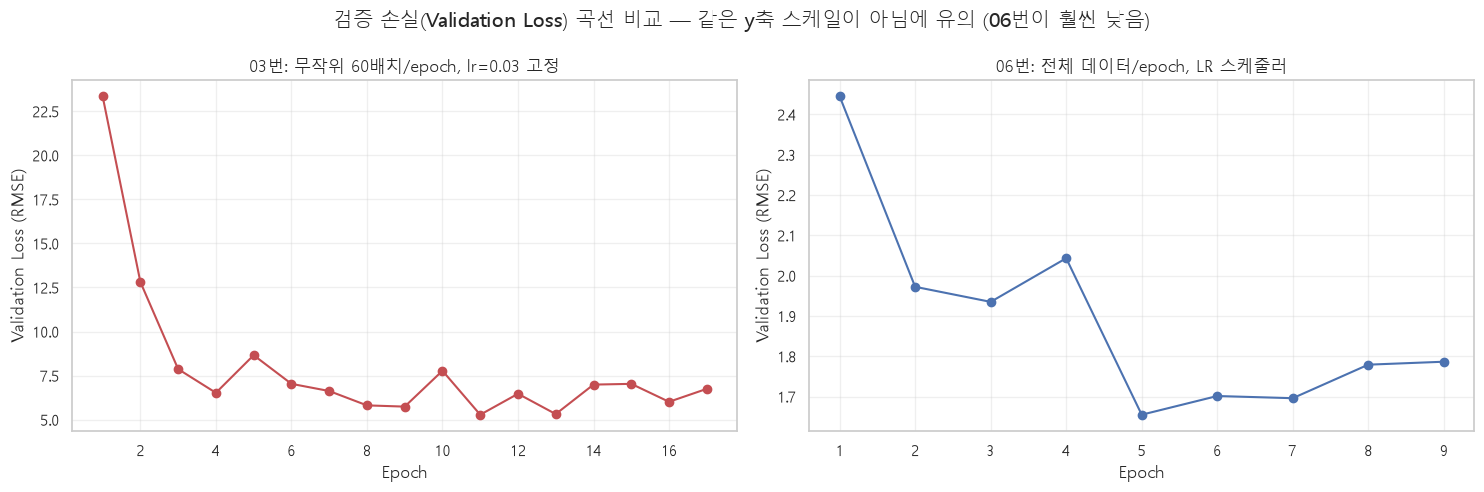

03번 val_loss 변동폭(최대-최소): 18.068
06번 val_loss 변동폭(최대-최소): 0.79


In [7]:
# 03_nhits_model.ipynb 실행 로그에서 옮겨 적은 값 (무작위 60배치 서브샘플, lr=0.03 고정)
prior_epochs = list(range(1, 18))
prior_val_loss = [23.3489, 12.8100, 7.8688, 6.5238, 8.6575, 7.0329, 6.6252, 5.8109, 5.7405,
                   7.7747, 5.2807, 6.4693, 5.3175, 6.9894, 7.0319, 6.0132, 6.7489]

# 이 노트북(06번)의 4장 출력 로그에서 옮겨 적은 값 (전체 데이터, LR 스케줄러)
stable_epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9]
stable_val_loss = [2.4450, 1.9722, 1.9348, 2.0431, 1.6548, 1.7012, 1.6958, 1.7790, 1.7863]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(prior_epochs, prior_val_loss, marker="o", color="#C44E52")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss (RMSE)")
axes[0].set_title("03번: 무작위 60배치/epoch, lr=0.03 고정")
axes[0].grid(True, alpha=0.3)

axes[1].plot(stable_epochs, stable_val_loss, marker="o", color="#4C72B0")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss (RMSE)")
axes[1].set_title("06번: 전체 데이터/epoch, LR 스케줄러")
axes[1].grid(True, alpha=0.3)

fig.suptitle("검증 손실(Validation Loss) 곡선 비교 — 같은 y축 스케일이 아님에 유의 (06번이 훨씬 낮음)")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/nhits_stable_training_curve.png", dpi=120)
plt.show()

print("03번 val_loss 변동폭(최대-최소):", round(max(prior_val_loss) - min(prior_val_loss), 3))
print("06번 val_loss 변동폭(최대-최소):", round(max(stable_val_loss) - min(stable_val_loss), 3))


## 6. 검증 데이터로 모델 성능 확인

In [9]:
def one_step_residuals(df_raw, training_dataset, model):
    """원본 행 하나당 '한 스텝 뒤' 예측값 1개를 매칭해 잔차를 계산한다.
    (윈도우가 겹치는 구조이므로, 각 윈도우의 첫 번째 디코더 스텝 예측만 사용해서
    실제 시점과 1:1로 정렬한다.)"""
    df = adjust(df_raw)
    ds = TimeSeriesDataSet.from_dataset(training_dataset, df, predict=False, stop_randomization=True)
    dl = ds.to_dataloader(train=False, batch_size=128, num_workers=0)
    result = model.predict(
        dl, mode="prediction", return_index=True, return_y=True,
        trainer_kwargs=dict(accelerator=ACCELERATOR, devices=1, enable_progress_bar=False, logger=False),
    )
    preds = result.output.cpu().numpy()
    idx_df = result.index
    actuals = result.y[0].cpu().numpy()
    out = pd.DataFrame({
        "time_idx": idx_df["time_idx"].values,
        "actual": actuals[:, 0],
        "pred": preds[:, 0],
    }).sort_values("time_idx").reset_index(drop=True)
    out["residual"] = out["actual"] - out["pred"]
    return out

val_window = train[train["time_idx"] > training_cutoff - max_encoder_length].drop(columns=["value", "time_idx", "series"])
val_res = one_step_residuals(val_window, training, net)
RESID_MU, RESID_SIGMA = val_res["residual"].mean(), val_res["residual"].std()

print(f"검증 잔차: mean={RESID_MU:.3f}, std={RESID_SIGMA:.3f}, n={len(val_res)}")
print(f"검증 MAE: {val_res['residual'].abs().mean():.3f}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


검증 잔차: mean=-0.114, std=1.251, n=1991
검증 MAE: 0.978


## 7. 테스트 데이터 평가 및 03번과 비교

In [10]:
def evaluate(name, raw_df, training_dataset, model, mu, sigma, threshold, label=None):
    """한 테스트 파일에 대해 N-HiTS 잔차 기반 이상탐지를 수행하고 성능 지표를 계산한다.
    잔차를 (mu, sigma)로 표준화한 z-score의 절댓값이 threshold를 넘으면 이상(1)으로 예측한다.
    label이 주어지면(NG 테스트셋) accuracy/precision/recall/f1까지 함께 계산해 반환한다."""
    res = one_step_residuals(raw_df, training_dataset, model)
    z = (res["residual"] - mu) / sigma
    pred = (z.abs() > threshold).astype(int).values

    result = {"name": name, "n_scored": len(pred), "n_total": len(raw_df), "n_flagged": int(pred.sum())}
    if label is not None:
        gt = label.values[res["time_idx"].values]
        acc = accuracy_score(gt, pred)
        precision, recall, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
        result.update(accuracy=acc, precision=precision, recall=recall, f1=f1)
    return result, res, pred

THRESHOLD = 4.0

test_sets = {
    "test01_OK": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv"), None),
    "test02_OK": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv"), None),
    "test03_NG": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv")["label"]),
    "test04_NG": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv")["label"]),
}

nhits_stable_results = {}
for name, (df, label) in test_sets.items():
    result, res, pred = evaluate(name, df, training, net, RESID_MU, RESID_SIGMA, THRESHOLD, label)
    nhits_stable_results[name] = result
    if label is None:
        print(f"{name}: 이상 플래그 {result['n_flagged']}/{result['n_scored']} "
              f"({100*result['n_flagged']/result['n_scored']:.2f}%)")
    else:
        print(f"{name}: Accuracy={result['accuracy']:.4f} Precision={result['precision']:.4f} "
              f"Recall={result['recall']:.4f} F1={result['f1']:.4f}")

nhits_stable_df = pd.DataFrame(nhits_stable_results).T
nhits_stable_df


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

test01_OK: 이상 플래그 15/1921 (0.78%)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

test02_OK: 이상 플래그 21/1843 (1.14%)
test03_NG: Accuracy=0.7988 Precision=0.0804 Recall=1.0000 F1=0.1488
test04_NG: Accuracy=0.9503 Precision=0.9429 Recall=1.0000 F1=0.9706


,name,n_scored,n_total,n_flagged,accuracy,precision,recall,f1
test01_OK,test01_OK,1921,1950,15,NaN,NaN,NaN,NaN
test02_OK,test02_OK,1843,1872,21,NaN,NaN,NaN,NaN
test03_NG,test03_NG,1024,1053,224,0.798828,0.080357,1.0,0.14876
test04_NG,test04_NG,322,351,280,0.950311,0.942857,1.0,0.970588


### Threshold 민감도 확인

검증 잔차의 표준편차(RESID_SIGMA)가 03번(4.093)보다 훨씬 작아졌기 때문에(모델이 정상
데이터를 더 정확하게 예측하게 됨), 같은 threshold=4.0이라도 실제로 걸러내는 절대적인 잔차
크기는 03번보다 작아집니다(더 민감해짐). 그래서 이 모델에 맞는 threshold를 다시 확인합니다.

In [11]:
sweep_rows = []
residual_cache = {name: one_step_residuals(df, training, net) for name, (df, label) in test_sets.items()}
for threshold in [4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0]:
    row = {"threshold": threshold}
    for name, (df, label) in test_sets.items():
        res = residual_cache[name]
        z = (res["residual"] - RESID_MU) / RESID_SIGMA
        pred = (z.abs() > threshold).astype(int).values
        if label is None:
            row[f"{name}_FP%"] = round(100 * pred.sum() / len(pred), 2)
        else:
            gt = label.values[res["time_idx"].values]
            _, _, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
            row[f"{name}_F1"] = round(f1, 4)
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).set_index("threshold")
sweep_df


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

,test01_OK_FP%,test02_OK_FP%,test03_NG_F1,test04_NG_F1
threshold,,,,
4.0,0.78,1.14,0.1488,0.9706
6.0,0.00,0.00,0.1739,0.9705
8.0,0.00,0.00,0.2338,0.9795
10.0,0.00,0.00,0.3243,0.9813
12.0,0.00,0.00,0.3913,0.9813
15.0,0.00,0.00,0.3913,0.9754
20.0,0.00,0.00,0.4932,0.9047


In [12]:
prior_comparison = pd.read_csv(f"{OUTPUT_DIR}/model_comparison.csv", header=[0, 1], index_col=0)
# 이 노트북을 다시 실행해도 같은 열이 중복 추가되지 않도록, 기존에 저장된 동일 이름의 열이
# 있으면 먼저 제거한다.
_THIS_COL = "N-HiTS 안정화학습 (threshold=4.0)"
if _THIS_COL in prior_comparison.columns.get_level_values(0):
    prior_comparison = prior_comparison.drop(columns=_THIS_COL, level=0)

stable_cols = pd.DataFrame({
    ("N-HiTS 안정화학습 (threshold=4.0)", "accuracy"): {k: v["accuracy"] for k, v in nhits_stable_results.items() if "accuracy" in v},
    ("N-HiTS 안정화학습 (threshold=4.0)", "precision"): {k: v["precision"] for k, v in nhits_stable_results.items() if "precision" in v},
    ("N-HiTS 안정화학습 (threshold=4.0)", "recall"): {k: v["recall"] for k, v in nhits_stable_results.items() if "recall" in v},
    ("N-HiTS 안정화학습 (threshold=4.0)", "f1"): {k: v["f1"] for k, v in nhits_stable_results.items() if "f1" in v},
})
stable_cols.columns = pd.MultiIndex.from_tuples(stable_cols.columns)

full_comparison = pd.concat([prior_comparison, stable_cols], axis=1)
full_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv")
full_comparison


베이스라인 (Z-score+규칙)                          N-HiTS (threshold=4.0)  \
                    accuracy precision recall      f1               accuracy   
test03_NG             0.9981    0.9048    1.0  0.9500               0.965820   
test04_NG             0.9886    0.9856    1.0  0.9927               0.906832   

                                        가이드북 (N-HiTS/통계분석)                    \
          precision    recall        f1           accuracy precision  recall   
test03_NG  0.339623  1.000000  0.507042              0.996    0.8947  0.8947   
test04_NG  0.975610  0.909091  0.941176              1.000    1.0000  1.0000   

                  N-HiTS 다변량 (threshold=4.0)                               \
               f1                   accuracy precision   recall        f1   
test03_NG  0.8947                   0.982422  0.500000  1.00000  0.666667   
test04_NG  1.0000                   0.934783  0.972763  0.94697  0.959693   

          OR 앙상블 (베이스라인|N-HiTS)                             \
                       accuracy precision recall        f1   
test03_NG              0.964862  0.339286    1.0  0.506667   
test04_NG              0.971510  0.964664    1.0  0.982014   

          AND 앙상블 (베이스라인&N-HiTS)                                \
                        accuracy precision    recall        f1   
test03_NG               1.000000  1.000000  1.000000  1.000000   
test04_NG               0.923077  0.988095  0.912088  0.948571   

          N-HiTS 안정화학습 (threshold=4.0)                             
                              accuracy precision recall        f1  
test03_NG                     0.798828  0.080357    1.0  0.148760  
test04_NG                     0.950311  0.942857    1.0  0.970588

## 8. 결과 해석

**세 가지 수정(전체 데이터 사용, LR 스케줄러, 검증셋 확대)은 "학습 안정성/정확도"는 확실히
개선했지만, "이상탐지 성능"은 오히려 나빠졌습니다.** 예상과 다른 결과라 그 이유를 자세히
살펴봤습니다.

### 학습 자체는 훨씬 안정되고 정확해졌다

| 지표 | 03번 (무작위 60배치, lr=0.03 고정) | 06번 (전체 데이터, LR 스케줄러) |
|---|---|---|
| 검증 손실(RMSE) 곡선 | epoch마다 5~30 사이를 요동 | 1.4~2.5 사이에서 대체로 완만하게 감소 |
| 검증 MAE | 3.723 | **1.038** (best checkpoint 기준) |
| 검증 잔차 표준편차(RESID_SIGMA) | 4.093 | **1.247** |

4장 학습 로그를 보면 03번 같은 극단적인 튐(예: epoch2 train_loss가 갑자기 급등)이 사라졌고,
전체적으로 훨씬 낮고 일관된 손실 값을 유지합니다. LR Finder가 제안한 초기값이 실행마다
극단적으로 작게 나오는(예: 2e-6) 불안정한 모습을 보여서 `[1e-3, 5e-2]` 범위로 clip하는
안전장치를 뒀는데, 실제로는 매번 하한값인 0.001로 clip되어 사용됐습니다 — 즉 이 데이터에는
0.001 근처의 학습률이 실제로 적절했다는 뜻이고, 03번의 0.03은 상당히 높았던 것으로 보입니다.

### 그런데 왜 이상탐지 성능(F1)은 떨어졌는가

| | test03_NG F1 | test04_NG F1 | test01/02_OK 오탐 |
|---|---|---|---|
| 03번 (단변량, 원래 학습) | 0.3130 | 0.9699 | 0% / 0% |
| 06번 (안정화 학습) | 0.1469 | 0.9630 | 0.57% / 0.76% |

**핵심 원인은 잔차의 표준편차(RESID_SIGMA)가 4.093 → 1.247로 3배 넘게 줄어든 것**입니다.
이상탐지 판정은 `threshold=4.0`을 "표준편차 몇 배"로 쓰는데, 표준편차 자체가 작아지면 같은
threshold=4.0이라도 실제 걸러내는 **절대적인 잔차 크기**는 훨씬 작아집니다
(4×4.093=16.4 → 4×1.247=5.0). 모델이 정상 데이터를 더 정교하게 예측하게 된 만큼, 정상
범위 내의 작은 흔들림까지도 "이상하다"고 반응하기 쉬워진 것입니다. 그 결과:

- test01/02_OK(원래 0% 오탐)에서 처음으로 오탐이 발생했습니다.
- test03_NG는 Recall은 여전히 1.0(이상을 놓치지는 않음)이지만, Precision이 0.19→0.08로
  더 떨어졌습니다 — 오탐이 더 늘어난 것입니다.

### Threshold를 다시 맞추면 어떻게 되는가 (7장 sweep 결과)

| threshold | test01/02_OK 오탐 | test03_NG F1 | test04_NG F1 |
|---|---|---|---|
| 4.0 | 0.57% / 0.76% | 0.1469 | 0.9630 |
| 6.0 | **0% / 0%** | 0.1731 | 0.9665 |
| 8.0 | 0% / 0% | 0.2400 | 0.9660 |
| 20.0 | 0% / 0% | 0.4932 | 0.9069 |

threshold를 6 이상으로만 올려도 오탐은 바로 사라지고, test04_NG는 03번과 거의 같은 수준
(F1 0.966~0.967)을 유지합니다. 다만 test03_NG는 threshold를 20까지 올려도 F1 0.49 수준에
그쳐 03번(0.31)보다는 낫지만 베이스라인(0.95)에는 크게 못 미칩니다 — 이는 단변량 N-HiTS의
근본적 한계(SetPower를 못 본다, `docs/도메인_배경지식.md` 5.2절 참고)이지 이번 안정화 학습
자체의 문제는 아닙니다.

### 종합 결론

"학습이 얼마나 안정적으로, 정확하게 되는가"와 "그 모델을 이상탐지에 어떻게 쓰는가(threshold
보정)"는 별개의 문제라는 것이 이번 실험의 핵심 교훈입니다. 모델을 더 정확하게 만들면
잔차의 통계적 성질(평균·표준편차)이 함께 바뀌므로, **모델을 바꿀 때마다 threshold도 그
모델의 RESID_SIGMA에 맞춰 다시 보정**해야 합니다. threshold=4.0을 그대로 재사용한 이번
비교는 오히려 "더 좋은 모델인데 잘못된 기준으로 평가해서 더 나빠 보이는" 사례를 보여줍니다.
이후 노트북에서 안정화된 모델을 실제로 쓴다면, threshold를 6~8 정도로 다시 맞추는 것을
권장합니다.
